# Quant Portfolio Optimizer

**Author** : Florent Yigbe  
**Program** : BSc, Mathematics in Business and Economics \
**Date** : March to May 2026

---

## Overview

A quantitative portfolio optimizer built in Python, applied to a diversified  
universe of 10 global assets. The optimizer uses Monte Carlo simulation to approximate  
the efficient frontier, selects the Max Sharpe and Min Variance portfolios, and evaluates  
their risk profiles through standard industry metrics.

The project is structured as follows:

| Step | Section | Description |
|------|---------|-------------|
| 1 | Data Collection | 10 years of adjusted price data, daily returns |
| 2 | Asset Risk Metrics | Annualized return, volatility, Sharpe, correlation heatmap |
| 3 | Monte Carlo Optimization | 10,000 random portfolios, efficient frontier approximation |
| 4 | Portfolio Metrics | Max Sharpe vs Min Variance vs Equal-Weight benchmark |
| 5 | Sharpe Ratio | Risk-adjusted performance comparison |
| 6 | VaR & CVaR | Historical downside risk at 95% and 99% confidence |
| 7 | Maximum Drawdown | Worst peak-to-trough loss, Calmar Ratio |
| 8 | Train / Test Split | In-sample optimization (2016–2022), out-of-sample evaluation (2023–2026) |
| 9 | Conclusions | Results summary, limitations, possible extensions |

---

## Step 1 - Data Collection

10 assets selected across geographies and asset classes to ensure genuine diversification:

| Ticker | Name | Sector / Region |
|--------|------|-----------------|
| NVDA | NVIDIA | US - Technology |
| MSFT | Microsoft | US - Technology |
| JPM | JPMorgan Chase | US - Financials |
| XOM | ExxonMobil | US - Energy |
| ASML | ASML Holding | Europe - Semiconductors |
| MC.PA | LVMH | Europe - Luxury |
| SAP | SAP SE | Europe - Software |
| NESN.SW | Nestlé | Europe - Consumer Staples |
| GLD | SPDR Gold ETF | Commodities - Gold |
| TLT | iShares 20Y Treasury | Fixed Income - US Bonds |

Prices downloaded via `yfinance` with `auto_adjust=True` to account for dividends and splits.  
Daily simple returns computed as $r_t = (P_t - P_{t-1}) / P_{t-1}$.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

#--------------------------------------------------------- Universe & parameters ---------------------------------------------------------

TICKERS    = ['NVDA', 'MSFT', 'JPM', 'XOM',
              'ASML', 'MC.PA', 'SAP', 'NESN.SW',
              'GLD', 
              'TLT']
START      = '2016-01-01'
END        = '2026-01-01'
RF         = 0.04       # Annual risk-free rate: 4% (approx. US 10Y Treasury)
PORT_VALUE = 10_000     # Hypothetical portfolio size: €10,000
n          = len(TICKERS)

#---------------------------------------------------- Download adjusted closing prices----------------------------------------------------

data = yf.download(TICKERS, start=START, end=END, auto_adjust=True)['Close']
data.dropna(how='all', inplace=True)
data.ffill(inplace=True)   # forward-fill sporadic NaNs (e.g. NESN.SW on US holidays)
data.dropna(inplace=True)

# --------------------------------------- Daily simple returns: r_t = (P_t - P_{t-1}) / P_{t-1} ------------------------------------------

returns = data.pct_change().dropna()

print(f"{len(returns)} trading days  -  {n} assets  -  From {START} to {END}")
data.head()

[*********************100%***********************]  10 of 10 completed

2583 trading days  -  10 assets  -  From 2016-01-01 to 2026-01-01


Ticker,ASML,GLD,JPM,MC.PA,MSFT,NESN.SW,NVDA,SAP,TLT,XOM
Date,,,,,,,,,,
2016-01-04,78.675880,102.889999,48.401131,114.797813,47.874195,53.081936,0.789545,64.865395,91.342461,49.654373
2016-01-05,77.882812,103.180000,48.484825,115.004028,48.092598,53.262371,0.802229,64.722427,90.973969,50.077454
2016-01-06,76.251640,104.669998,47.784908,112.736092,47.218975,52.721081,0.769056,65.294243,92.199860,49.660789
2016-01-07,74.341049,106.150002,45.852501,112.653618,45.576576,51.494167,0.738567,64.924240,92.365280,48.865898
2016-01-08,72.349373,105.680000,44.825443,111.622757,45.716343,50.736378,0.722713,64.663589,92.778915,47.878731


## Step 2 - Individual Asset Risk Metrics

Three core metrics annualized using the 252 trading days convention:

$$\text{Annualized Return} = \bar{r} \times 252$$

$$\text{Annualized Volatility} = \sigma_{\text{daily}} \times \sqrt{252}$$

$$\text{Sharpe Ratio} = \frac{\mu_{\text{ann}} - R_f}{\sigma_{\text{ann}}}$$

where $R_f = 4\%$ is the risk-free rate (approximate US 10Y Treasury yield).

The correlation heatmap reveals diversification opportunities: GLD and TLT show low or negative  
correlation with equities, reducing portfolio variance through the covariance term $\mathbf{w}^\top \Sigma \mathbf{w}$.

In [2]:
# -------------------------------------------------- Annualized statistics per asset -----------------------------------------------------

mean_return = returns.mean() * 252   #annualized return
volatility  = returns.std()  * np.sqrt(252)  #annualized volatility
cov_matrix  = returns.cov()  * 252   # annualized covariance matrix

risk_df = pd.DataFrame({
    'Ann. Return'    : mean_return,
    'Ann. Volatility': volatility,
    'Sharpe Ratio'   : (mean_return - RF) / volatility
}).round(4)

print("Individual Asset Risk Metrics (annualized)\n")
print(risk_df.to_string())

Individual Asset Risk Metrics (annualized)

         Ann. Return  Ann. Volatility  Sharpe Ratio
Ticker                                             
ASML          0.3238           0.3719        0.7631
GLD           0.1423           0.1460        0.7004
JPM           0.2210           0.2720        0.6653
MC.PA         0.2047           0.2757        0.5974
MSFT          0.2603           0.2639        0.8347
NESN.SW       0.0476           0.1618        0.0472
NVDA          0.6537           0.4922        1.2470
SAP           0.1634           0.2674        0.4613
TLT           0.0049           0.1478       -0.2375
XOM           0.1235           0.2748        0.3039


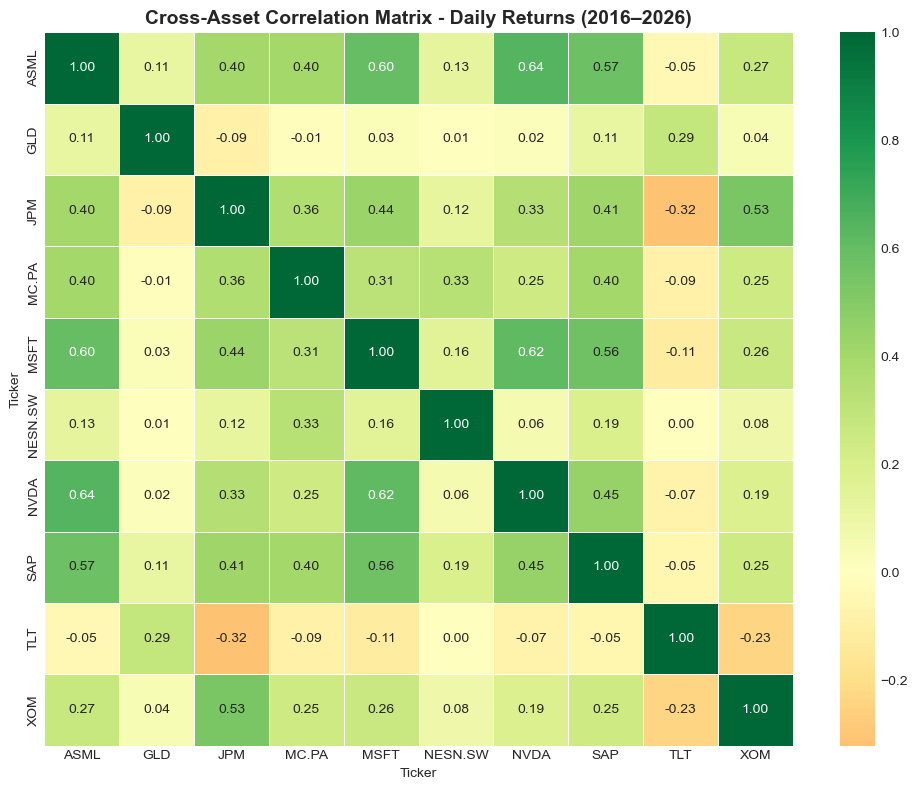

In [3]:
#---------------------------------------------------------- Correlation heatmap ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
ax.set_title('Cross-Asset Correlation Matrix - Daily Returns (2016–2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3 - Monte Carlo Optimization

For each of 10,000 simulated portfolios:

1. Draw $n$ uniform random numbers, normalize to sum to 1 - weights $\mathbf{w}$
2. Annualized portfolio return: $r_p = \mathbf{w}^\top \boldsymbol{\mu}$
3. Annualized portfolio volatility: $\sigma_p = \sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}$
4. Sharpe ratio: $S = (r_p - R_f) / \sigma_p$

Two reference portfolios are extracted from the simulation:
- **Max Sharpe** - maximizes risk-adjusted return
- **Min Variance** - minimizes total volatility

> Monte Carlo approximates the frontier by sampling - it does not guarantee the true optimum.  
> A `cvxpy` quadratic program would find the exact solution. The simulation is used here  
> for its intuitive visualization: the scatter cloud makes the frontier shape immediately legible.

In [4]:
np.random.seed(3)   
SCENARIOS = 10_000

# ---------------------------------------------------- Pre-allocate arrays for speed -----------------------------------------------------

weights_array    = np.zeros((SCENARIOS, n))
returns_array    = np.zeros(SCENARIOS)
volatility_array = np.zeros(SCENARIOS)
sharpe_array     = np.zeros(SCENARIOS)

for index in range(SCENARIOS):
    # Step 1: random weights summing to 1 (long-only: no short selling)
    numbers = np.random.random(n)
    weights = numbers / np.sum(numbers)

    # Step 2: compute and store portfolio metrics
    port_ret = np.sum(returns.mean() * 252 * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    weights_array[index]    = weights
    returns_array[index]    = port_ret
    volatility_array[index] = port_vol
    sharpe_array[index]     = (port_ret - RF) / port_vol

# ------------------------------------------------------ Identify optimal portfolios -----------------------------------------------------

idx_ms = sharpe_array.argmax()
idx_mv = volatility_array.argmin()

w_optimal      = weights_array[idx_ms]
ret_optimal    = returns_array[idx_ms]
vol_optimal    = volatility_array[idx_ms]
sharpe_optimal = sharpe_array[idx_ms]

ret_minvol     = returns_array[idx_mv]
vol_minvol     = volatility_array[idx_mv]
sharpe_minvol  = sharpe_array[idx_mv]

print(f"{SCENARIOS:,} portfolios simulated")
print(f"\n Max Sharpe Portfolio")
print(f"   Annualized Return  : {ret_optimal:.2%}")
print(f"   Annualized Vol     : {vol_optimal:.2%}")
print(f"   Sharpe Ratio       : {sharpe_optimal:.2f}")
print(f"\n Min Variance Portfolio")
print(f"   Annualized Return  : {ret_minvol:.2%}")
print(f"   Annualized Vol     : {vol_minvol:.2%}")
print(f"   Sharpe Ratio       : {sharpe_minvol:.2f}")
print(f"\n Optimal Weights (Max Sharpe):")
for ticker, w in zip(TICKERS, w_optimal):
    print(f"   {ticker:<10} {w:.1%}")

10,000 portfolios simulated

 Max Sharpe Portfolio
   Annualized Return  : 27.20%
   Annualized Vol     : 17.69%
   Sharpe Ratio       : 1.31

 Min Variance Portfolio
   Annualized Return  : 12.96%
   Annualized Vol     : 10.06%
   Sharpe Ratio       : 0.89

 Optimal Weights (Max Sharpe):
   NVDA       1.9%
   MSFT       25.4%
   JPM        8.7%
   XOM        6.4%
   ASML       10.1%
   MC.PA      7.3%
   SAP        22.4%
   NESN.SW    6.9%
   GLD        2.9%
   TLT        8.0%


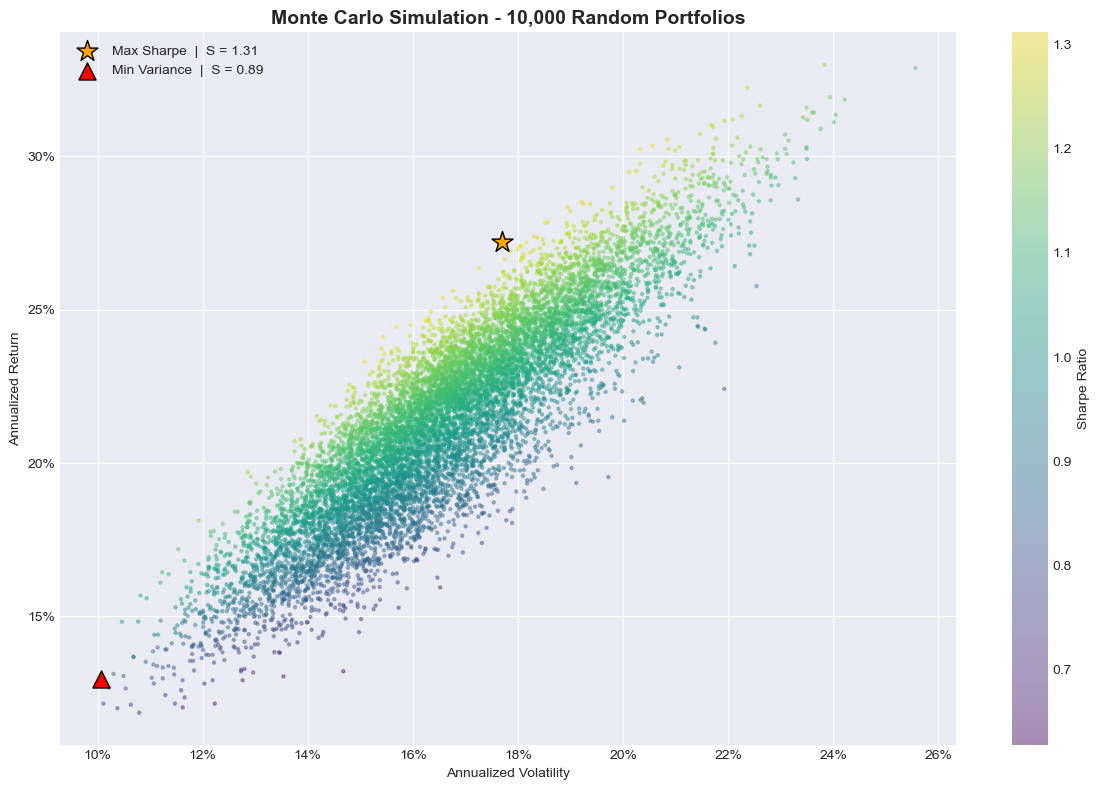

In [5]:
# ----------------------------------------------- Efficient frontier - scatter plot ------------------------------------------------------

# Each dot is one simulated portfolio.
# Color = Sharpe ratio. The cloud shape traces the efficient frontier.

plt.figure(figsize=(12, 8))
plt.scatter(volatility_array, returns_array,
            c=sharpe_array, cmap='viridis', alpha=0.4, s=5)
plt.colorbar(label='Sharpe Ratio')

plt.scatter(vol_optimal, ret_optimal,
            c='orange', edgecolors='black', s=250, zorder=5, marker='*',
            label=f'Max Sharpe  |  S = {sharpe_optimal:.2f}')
plt.scatter(vol_minvol, ret_minvol,
            c='red', edgecolors='black', s=150, zorder=5, marker='^',
            label=f'Min Variance  |  S = {sharpe_minvol:.2f}')

plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Monte Carlo Simulation - 10,000 Random Portfolios',
          fontsize=14, fontweight='bold')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

## Step 4 - Portfolio Metrics & Allocation

Three strategies compared:

| Strategy | Description |
|----------|-------------|
| **Max Sharpe** | Maximizes Sharpe ratio - highest risk-adjusted return |
| **Min Variance** | Minimizes total volatility regardless of return |
| **Equal-Weight** |  $1/n$ benchmark - 10% per asset |

In [6]:
# -------------------------------------------------------- Equal-weight baseline ---------------------------------------------------------

weights_ew  = np.array([1/n] * n)
port_ret_ew = np.sum(returns.mean() * 252 * weights_ew)
port_vol_ew = np.sqrt(np.dot(weights_ew.T, np.dot(cov_matrix, weights_ew)))
sharpe_ew   = (port_ret_ew - RF) / port_vol_ew

print(" PORTFOLIO METRICS COMPARISON")
print("=" * 62)
print(f"   {'':26} {'Max Sharpe':>12} {'Min Variance':>12} {'Equal-Weight':>12}")
print("-" * 62)
print(f"   {'Annualized Return':<26} {ret_optimal:>12.2%} {ret_minvol:>12.2%} {port_ret_ew:>12.2%}")
print(f"   {'Annualized Volatility':<26} {vol_optimal:>12.2%} {vol_minvol:>12.2%} {port_vol_ew:>12.2%}")
print(f"   {'Sharpe Ratio':<26} {sharpe_optimal:>12.2f} {sharpe_minvol:>12.2f} {sharpe_ew:>12.2f}")
print("=" * 62)

 PORTFOLIO METRICS COMPARISON
                                Max Sharpe Min Variance Equal-Weight
--------------------------------------------------------------
   Annualized Return                27.20%       12.96%       21.45%
   Annualized Volatility            17.69%       10.06%       16.11%
   Sharpe Ratio                       1.31         0.89         1.08


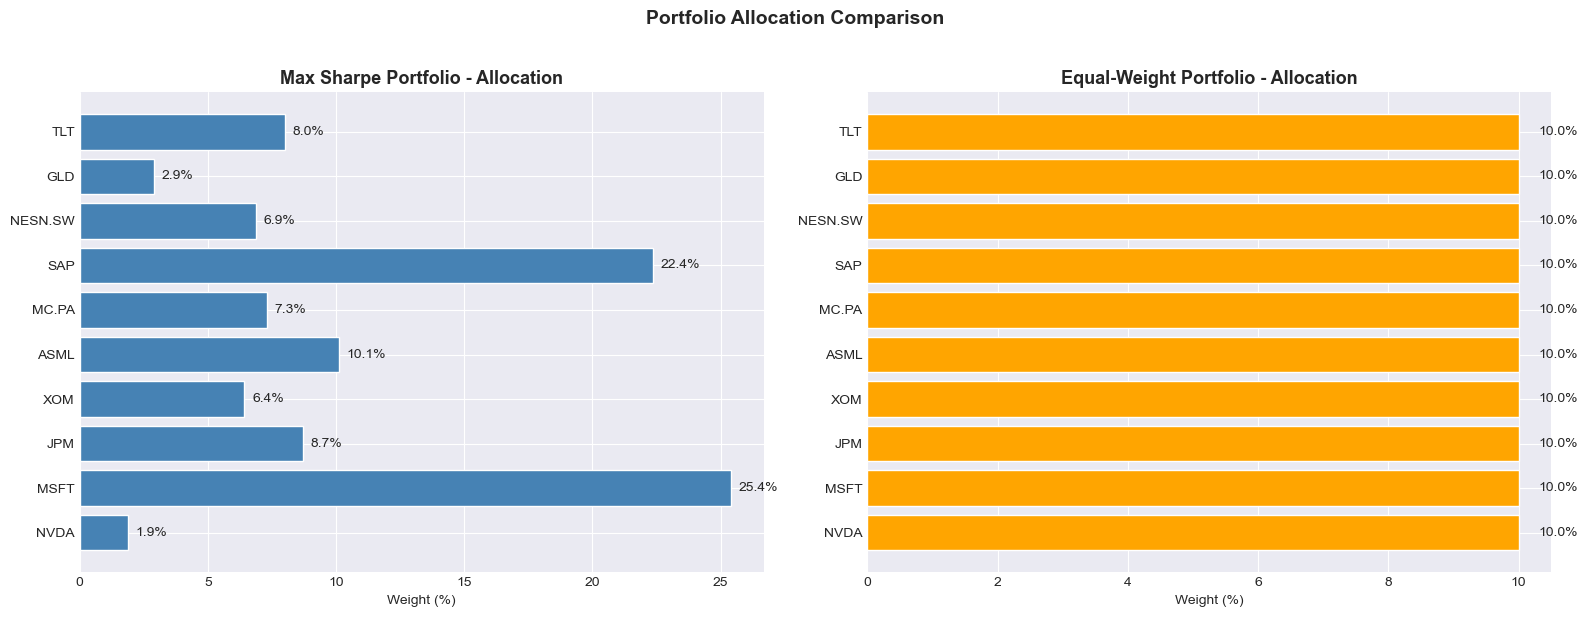

In [7]:
# -------------------------------------------------------- Allocation comparison ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Max Sharpe weights
axes[0].barh(TICKERS, w_optimal * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Weight (%)')
axes[0].set_title('Max Sharpe Portfolio - Allocation',
                  fontsize=13, fontweight='bold')
for i, w in enumerate(w_optimal):
    axes[0].text(w * 100 + 0.3, i, f'{w:.1%}', va='center', fontsize=10)

# Equal-weight
axes[1].barh(TICKERS, weights_ew * 100, color='orange', edgecolor='white')
axes[1].set_xlabel('Weight (%)')
axes[1].set_title('Equal-Weight Portfolio - Allocation',
                  fontsize=13, fontweight='bold')
for i, w in enumerate(weights_ew):
    axes[1].text(w * 100 + 0.3, i, f'{w:.1%}', va='center', fontsize=10)

plt.suptitle('Portfolio Allocation Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 5 - Sharpe Ratio

$$\text{Sharpe Ratio} = \frac{\mu_p - R_f}{\sigma_p}$$

| Range | Interpretation |
|-------|---------------|
| $< 1.0$ | Risk not adequately compensated |
| $1.0 – 1.5$ | Acceptable |
| $1.5 – 2.0$ | Good - above-average risk-adjusted performance |
| $> 2.0$ | Excellent - institutional quality |

In [8]:
sharpe_df = pd.DataFrame({
    'Ann. Return'    : [f'{port_ret_ew:.2%}', f'{ret_optimal:.2%}',   f'{ret_minvol:.2%}'],
    'Ann. Volatility': [f'{port_vol_ew:.2%}', f'{vol_optimal:.2%}',   f'{vol_minvol:.2%}'],
    'Sharpe Ratio'   : [f'{sharpe_ew:.2f}',   f'{sharpe_optimal:.2f}', f'{sharpe_minvol:.2f}']
}, index=['Equal-Weight', 'Max Sharpe (MC)', 'Min Variance (MC)'])

print(" Sharpe Ratio Comparison - All Portfolios\n")
print(sharpe_df.to_string())
print(f"\n→ Max Sharpe improves Sharpe by {sharpe_optimal - sharpe_ew:+.2f} vs equal-weight")

 Sharpe Ratio Comparison - All Portfolios

                  Ann. Return Ann. Volatility Sharpe Ratio
Equal-Weight           21.45%          16.11%         1.08
Max Sharpe (MC)        27.20%          17.69%         1.31
Min Variance (MC)      12.96%          10.06%         0.89

→ Max Sharpe improves Sharpe by +0.23 vs equal-weight


## Step 6 - Value at Risk & CVaR

**Value at Risk (VaR)** - maximum daily loss at a given confidence level:

$$\text{VaR}_{\alpha} = -\,\text{Percentile}(r_p,\; 1-\alpha)$$

**CVaR (Expected Shortfall)** - average loss conditional on being in the worst $\alpha\%$ of days:

$$\text{CVaR}_{\alpha} = -\,\mathbb{E}\!\left[r_p \mid r_p \leq \text{VaR}_{\alpha}\right]$$

Both computed using **historical simulation** - no distributional assumption required.  
Reported at 95% and 99% confidence levels as a percentage of portfolio value.

In [9]:
# ----------------------------------------------- Daily portfolio returns (Max Sharpe) ---------------------------------------------------

port_returns = (returns * w_optimal).sum(axis=1)
var_results  = {}

print("  VALUE AT RISK & CVaR - Max Sharpe Portfolio")
print(f"    Portfolio value : €{PORT_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns, alpha * 100)
    cvar_pct = port_returns[port_returns <= var_pct].mean()
    var_results[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORT_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORT_VALUE:,.0f})")
    print()

  VALUE AT RISK & CVaR - Max Sharpe Portfolio
    Portfolio value : €10,000

   Confidence level : 95%
   Historical VaR   : -1.65%  (= €-165)
   Historical CVaR  : -2.50%  (= €-250)

   Confidence level : 99%
   Historical VaR   : -3.10%  (= €-310)
   Historical CVaR  : -4.17%  (= €-417)



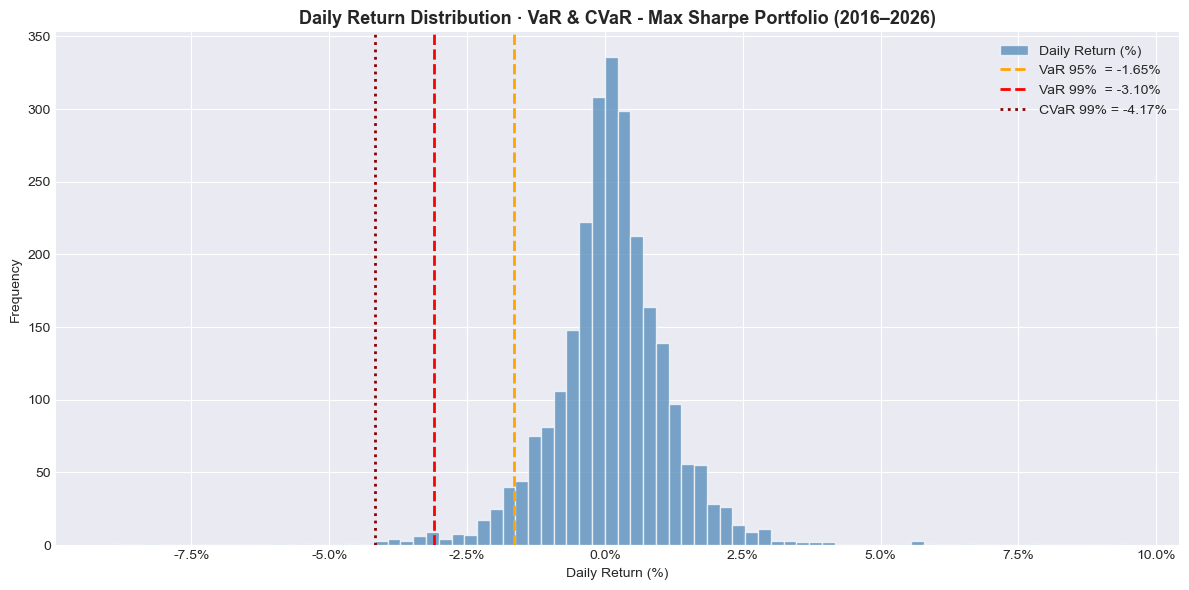

In [10]:
# -------------------------------------------------- P&L distribution with VaR lines -----------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(port_returns * 100, bins=80, alpha=0.7,
        color='steelblue', edgecolor='white', label='Daily Return (%)')

ax.axvline(var_results[0.95]['var_pct'] * 100, color='orange', lw=2, ls='--',
           label=f"VaR 95%  = {var_results[0.95]['var_pct']:.2%}")
ax.axvline(var_results[0.99]['var_pct'] * 100, color='red', lw=2, ls='--',
           label=f"VaR 99%  = {var_results[0.99]['var_pct']:.2%}")
ax.axvline(var_results[0.99]['cvar_pct'] * 100, color='darkred', lw=2, ls=':',
           label=f"CVaR 99% = {var_results[0.99]['cvar_pct']:.2%}")

ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Frequency')
ax.set_title('Daily Return Distribution · VaR & CVaR - Max Sharpe Portfolio (2016–2026)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.legend()
plt.tight_layout()
plt.show()

## Step 7 - Maximum Drawdown

**Maximum Drawdown (MDD)** - largest peak-to-trough decline over the full period:

$$\text{MDD} = \min_t \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}$$

**Calmar Ratio** - annualized return per unit of maximum drawdown, commonly reported  
alongside the Sharpe ratio in hedge fund contexts:

$$\text{Calmar Ratio} = \frac{\mu_p}{|\text{MDD}|}$$

 Max Drawdown  : -28.69%
 Calmar Ratio  : 0.95


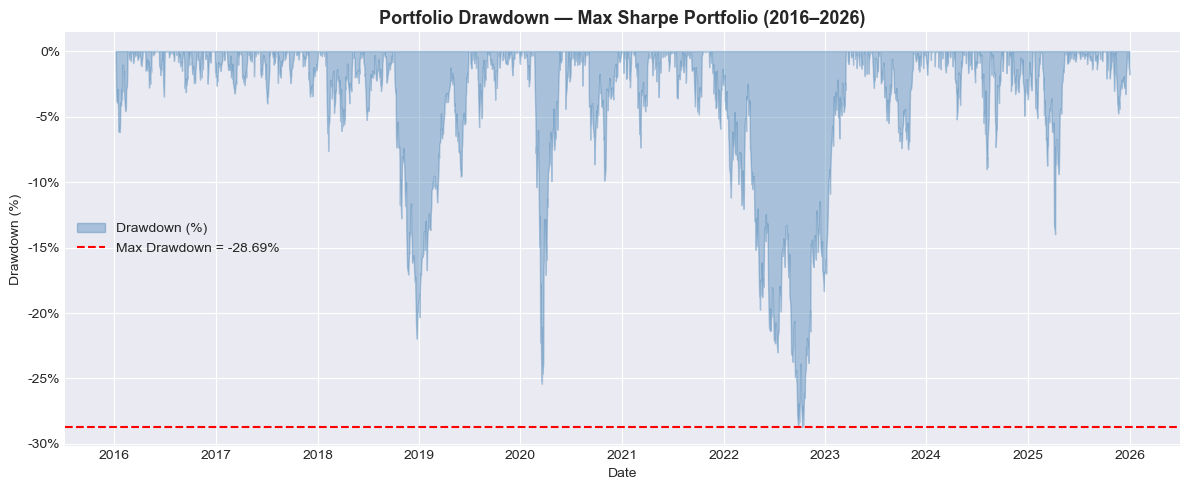

In [11]:
# ---------------------------------------------------------------- Max Drawdown ----------------------------------------------------------------

cum_returns  = (1 + port_returns).cumprod()
rolling_max  = cum_returns.cummax()
drawdown     = (cum_returns - rolling_max) / rolling_max
max_drawdown = drawdown.min()

calmar_ratio = ret_optimal / abs(max_drawdown)

print(f" Max Drawdown  : {max_drawdown:.2%}")
print(f" Calmar Ratio  : {calmar_ratio:.2f}")

# ------------------------------------------------------------- Drawdown chart -----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(drawdown.index, drawdown * 100, 0,
                color='steelblue', alpha=0.4, label='Drawdown (%)')
ax.axhline(max_drawdown * 100, color='red', lw=1.5, ls='--',
           label=f'Max Drawdown = {max_drawdown:.2%}')

ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Portfolio Drawdown — Max Sharpe Portfolio (2016–2026)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 - Test Split

To prevent **look-ahead bias**, the dataset is split temporally:

| Period | Window | Role |
|--------|--------|------|
| Train (in-sample) | 2016–2022 | Monte Carlo optimization |
| Test (out-of-sample) | 2023–2026 | Evaluation only - weights frozen |

The Max Sharpe weights are estimated exclusively on the training window,  
then applied unchanged to the test period. Performance is compared against  
the equal-weight benchmark on both periods to assess out-of-sample robustness.

In [12]:
# -------------------------------------------------------------- Temporal split ----------------------------------------------------------------

train = returns[:'2022-12-31']   # in-sample     : 2016 – 2022
test  = returns['2023-01-01':]   # out-of-sample : 2023 – 2026

print(f" Train : {train.index[0].date()}  →  {train.index[-1].date()}  ({len(train)} days)")
print(f" Test  : {test.index[0].date()}   →  {test.index[-1].date()}   ({len(test)} days)")

# -------------------------------------------- Monte Carlo on TRAIN data only -----------------------------------------------------------------

np.random.seed(3)

mu_train  = train.mean() * 252
cov_train = train.cov()  * 252

w_arr  = np.zeros((SCENARIOS, n))
r_arr  = np.zeros(SCENARIOS)
v_arr  = np.zeros(SCENARIOS)
s_arr  = np.zeros(SCENARIOS)

for i in range(SCENARIOS):
    numbers  = np.random.random(n)
    w        = numbers / np.sum(numbers)
    port_r   = np.sum(mu_train * w)
    port_v   = np.sqrt(np.dot(w.T, np.dot(cov_train, w)))
    w_arr[i] = w
    r_arr[i] = port_r
    v_arr[i] = port_v
    s_arr[i] = (port_r - RF) / port_v

w_train_ms = w_arr[s_arr.argmax()]

# ----------------------------------------------- Evaluate on TRAIN and TEST ------------------------------------------------------------------

def portfolio_metrics(weights, returns_df, label):
    port_ret = (returns_df * weights).sum(axis=1)
    ann_ret  = port_ret.mean() * 252
    ann_vol  = port_ret.std()  * np.sqrt(252)
    sharpe   = (ann_ret - RF)  / ann_vol
    cum      = (1 + port_ret).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f"   {label:<28} Return: {ann_ret:.2%}  Vol: {ann_vol:.2%}  Sharpe: {sharpe:.2f}  MaxDD: {mdd:.2%}")
    return ann_ret, ann_vol, sharpe, mdd

weights_ew_arr = np.array([1/n] * n)

print("\n IN-SAMPLE (2016–2022)")
print("-" * 75)
r_ms_in,  v_ms_in,  s_ms_in,  d_ms_in  = portfolio_metrics(w_train_ms,    train, 'Max Sharpe (MC)')
r_ew_in,  v_ew_in,  s_ew_in,  d_ew_in  = portfolio_metrics(weights_ew_arr, train, 'Equal-Weight')

print("\n OUT-OF-SAMPLE (2023–2026)")
print("-" * 75)
r_ms_out, v_ms_out, s_ms_out, d_ms_out = portfolio_metrics(w_train_ms,    test, 'Max Sharpe (MC)')
r_ew_out, v_ew_out, s_ew_out, d_ew_out = portfolio_metrics(weights_ew_arr, test, 'Equal-Weight')

 Train : 2016-01-05  →  2022-12-30  (1808 days)
 Test  : 2023-01-02   →  2025-12-31   (775 days)

 IN-SAMPLE (2016–2022)
---------------------------------------------------------------------------
   Max Sharpe (MC)              Return: 25.61%  Vol: 19.24%  Sharpe: 1.12  MaxDD: -27.29%
   Equal-Weight                 Return: 19.76%  Vol: 17.10%  Sharpe: 0.92  MaxDD: -26.90%

 OUT-OF-SAMPLE (2023–2026)
---------------------------------------------------------------------------
   Max Sharpe (MC)              Return: 33.01%  Vol: 16.69%  Sharpe: 1.74  MaxDD: -16.40%
   Equal-Weight                 Return: 25.39%  Vol: 13.52%  Sharpe: 1.58  MaxDD: -13.75%


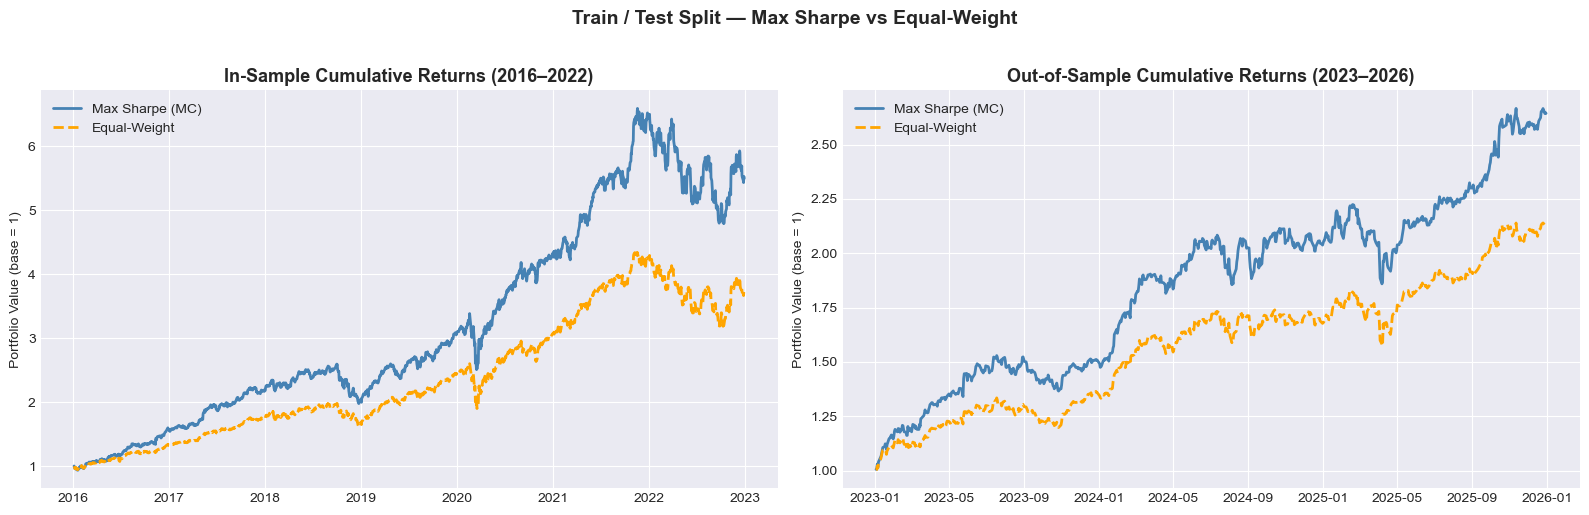

In [13]:
# --------------------------------------- Cumulative returns — in-sample vs out-of-sample -----------------------------------------------------

cum_ms_in  = (1 + (train * w_train_ms).sum(axis=1)).cumprod()
cum_ew_in  = (1 + (train * weights_ew_arr).sum(axis=1)).cumprod()
cum_ms_out = (1 + (test  * w_train_ms).sum(axis=1)).cumprod()
cum_ew_out = (1 + (test  * weights_ew_arr).sum(axis=1)).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(cum_ms_in.index, cum_ms_in,  color='steelblue', lw=2, label='Max Sharpe (MC)')
axes[0].plot(cum_ew_in.index, cum_ew_in,  color='orange',    lw=2, label='Equal-Weight',  ls='--')
axes[0].set_title('In-Sample Cumulative Returns (2016–2022)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (base = 1)')
axes[0].legend()

axes[1].plot(cum_ms_out.index, cum_ms_out, color='steelblue', lw=2, label='Max Sharpe (MC)')
axes[1].plot(cum_ew_out.index, cum_ew_out, color='orange',    lw=2, label='Equal-Weight',  ls='--')
axes[1].set_title('Out-of-Sample Cumulative Returns (2023–2026)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Portfolio Value (base = 1)')
axes[1].legend()

plt.suptitle('Train / Test Split — Max Sharpe vs Equal-Weight',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 9 - Conclusions

---

### Results Summary

| Metric | Max Sharpe - In-Sample | Max Sharpe - Out-of-Sample | Equal-Weight - Out-of-Sample |
|--------|------------------------|---------------------------|------------------------------|
| Ann. Return | 25.61% | 33.01% | 25.39% |
| Ann. Volatility | 19.24% | 16.69% | 13.52% |
| Sharpe Ratio | 1.12 | 1.74 | 1.58 |
| Max Drawdown | -27.29% | -16.40% | -13.75% |

---

### Limitations

**1. Estimation error in expected returns**  
Historical mean returns carry high estimation noise and are a poor predictor of future performance.  
Mean-variance optimization amplifies this error by concentrating weight in assets that happened  
to perform well in-sample - a phenomenon known as error maximization.

**2. Monte Carlo approximation**  
Sampling 10,000 random portfolios does not guarantee finding the true efficient frontier.  
A `cvxpy` quadratic program solves the exact Markowitz problem analytically and eliminates  
sampling noise entirely.

**3. No transaction costs**  
All returns are gross of trading costs. Bid-ask spreads, commissions, and market impact  
reduce net performance meaningfully when compounded over multi-year periods.

**4. Non-stationarity**  
The covariance matrix is estimated on the full training period and assumed constant.  
In practice, correlations and volatilities shift across market regimes - most sharply  
during stress periods when diversification is needed most.

**5. Single temporal split**  
An 80/20 train/test split is a minimal out-of-sample test. A walk-forward expanding window  
- re-optimizing annually on all available history - would give a more robust equity curve.

**6. Long-only constraint**  
Weights are restricted to $[0, 1]$. Relaxing this to allow short positions expands the  
feasible set and enables the optimizer to express negative views on overvalued assets.

*All results are historical backtests. Past performance does not predict future returns.  
This project does not constitute investment advice.*